# 📈 Homework: Lineární regrese – Modelování pevnosti betonu
**Cíl:** Sestavení baseline regresního modelu pomocí třídy `LinearRegression` ze Scikit-learn pro odhad pevnosti betonu v tlaku ($csMPa$).

### Kroky zadání:
1. Import potřebných knihoven z `Scikit-learn`, `Pandas`, `NumPy` a vizualizačních nástrojů.
2. Načtení předzpracovaného datasetu `concrete_data_preprocessed.csv`.
3. Rozdělení dat na trénovací a testovací sadu v poměru **70/30** (`test_size=0.3`, `random_state=42`).
4. Vytvoření instance modelu `LinearRegression` a přiřazení do proměnné **`linear_reg`**.
5. Natrénování modelu a otestování jeho efektivity na testovací sadě pomocí vybraných metrik ($R^2$, RMSE, MAE).
6. Interpretace naučených regresních koeficientů a diagnostika reziduí.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    root_mean_squared_error,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Nastavení zobrazení
pd.set_option('display.max_columns', 15)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


## 1. Načtení předzpracovaného datasetu
Načteme soubor `data/concrete_data_preprocessed.csv`, který obsahuje standardizované prediktory ($\mu=0, \sigma=1$) a cílovou proměnnou `csMPa` v megapascalech.


In [2]:
# Načtení dat
df = pd.read_csv('data/concrete_data_preprocessed.csv')

print(f"Rozměry datasetu: {df.shape[0]} řádků, {df.shape[1]} sloupců")
display(df.head(10))


Rozměry datasetu: 1005 řádků, 9 sloupců


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,2.5061,-0.8365,-0.8654,-0.9411,-0.5969,0.8463,-1.2041,-0.2803,79.9900
1,2.5061,-0.8365,-0.8654,-0.9411,-0.5969,1.0398,-1.2041,-0.2803,61.8900
2,0.5165,0.8181,-0.8654,2.1531,-1.0194,-0.5465,-2.2252,3.5186,40.2700
3,0.5165,0.8181,-0.8654,2.1531,-1.0194,-0.5465,-2.2252,5.0099,41.0500
4,-0.7673,0.7008,-0.8654,0.4653,-1.0194,0.0519,0.6577,4.9314,44.3000
5,-0.1211,0.4871,-0.8654,2.1531,-1.0194,-0.5465,-1.2788,0.6930,47.0300
6,0.9720,0.2665,-0.8654,2.1531,-1.0194,-0.5465,-2.2252,5.0099,43.7000
7,0.9720,0.2665,-0.8654,2.1531,-1.0194,-0.5465,-2.2252,-0.2803,36.4500
8,-0.1211,0.4871,-0.8654,2.1531,-1.0194,-0.5465,-1.2788,-0.2803,45.8500
9,1.8829,-0.8365,-0.8654,2.1531,-1.0194,-0.5465,-2.2252,-0.2803,39.2900


## 2. Rozdělení na trénovací a testovací sadu (70/30)
Oddělíme matici příznaků $X$ a cílový vektor $y$ a rozdělíme data v poměru **70 % trénovací / 30 % testovací**.


In [3]:
# Oddělení příznaků a cíle
X = df.drop(columns=['csMPa'])
y = df['csMPa']

# Rozdělení 70/30 se zafixovaným random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Trénovací sada (70 %): {X_train.shape[0]} vzorků")
print(f"Testovací sada (30 %): {X_test.shape[0]} vzorků")


Trénovací sada (70 %): 703 vzorků
Testovací sada (30 %): 302 vzorků


## 3. Vytvoření instance LinearRegression
Vytvoříme instanci třídy `LinearRegression` a přiřadíme ji přesně dle zadání do proměnné **`linear_reg`**.


In [4]:
# Vytvoření instance lineárního modelu
linear_reg = LinearRegression()
print("Model vytvořen:", linear_reg)


Model vytvořen: LinearRegression()


## 4. Natrénování modelu (fit)
Provedeme fitování modelu metodou nejmenších čtverců (OLS) na trénovacích datech.


In [5]:
# Trénování modelu
linear_reg.fit(X_train, y_train)
print("Model byl úspěšně natrénován!")


Model byl úspěšně natrénován!


## 5. Analýza naučených koeficientů ($\beta_j$ a $\beta_0$)
Jelikož vstupní data byla standardizována pomocí `StandardScaler` ($\sigma=1$), koeficienty $\beta_j$ přímo vyjadřují relativní důležitost (*Beta weights*).
Koeficient udává změnu pevnosti betonu v MPa při nárůstu dané složky o **1 směrodatnou odchylku**.


In [6]:
# Intercept a koeficienty
intercept = linear_reg.intercept_
coef_df = pd.DataFrame({
    'Proměnná': X.columns,
    'Beta koeficient (MPa/1σ)': linear_reg.coef_
}).sort_values(by='Beta koeficient (MPa/1σ)', ascending=False).reset_index(drop=True)

print(f"Intercept (beta_0): {intercept:.4f} MPa (průměrná výchozí pevnost)")
display(coef_df)


Intercept (beta_0): 35.1113 MPa (průměrná výchozí pevnost)


,Proměnná,Beta koeficient (MPa/1σ)
0,cement,12.7909
1,slag,9.2297
2,age,7.1289
3,flyash,6.0528
4,fineaggregate,2.3869
5,superplasticizer,2.0587
6,coarseaggregate,1.4404
7,water,-2.3174


## 6. Otestování efektivity na testovací sadě
Vypočteme predikce na testovací sadě a vyhodnotíme model pomocí klíčových regresních metrik:
- **$R^2$ (Koeficient determinace):** Podíl rozptylu cíle vysvětlený modelem.
- **RMSE (Root Mean Squared Error):** Odhad typické chyby v původních jednotkách (MPa), citlivý na velké odchylky.
- **MAE (Mean Absolute Error):** Robustní průměrná absolutní chyba v MPa.
- **MAPE (Mean Absolute Percentage Error):** Průměrná relativní chyba v procentech.


In [7]:
# Predikce
y_pred_train = linear_reg.predict(X_train)
y_pred_test = linear_reg.predict(X_test)

# Výpočet metrik
metrics_df = pd.DataFrame({
    'Metrika': ['R² (Koeficient determinace)', 'RMSE (Odmocnina MSE)', 'MAE (Absolutní chyba)', 'MAPE (Relativní chyba)'],
    'Trénovací sada (Train)': [
        f"{r2_score(y_train, y_pred_train):.4f} ({r2_score(y_train, y_pred_train)*100:.2f} %)",
        f"{root_mean_squared_error(y_train, y_pred_train):.4f} MPa",
        f"{mean_absolute_error(y_train, y_pred_train):.4f} MPa",
        f"{mean_absolute_percentage_error(y_train, y_pred_train)*100:.2f} %"
    ],
    'Testovací sada (Test)': [
        f"{r2_score(y_test, y_pred_test):.4f} ({r2_score(y_test, y_pred_test)*100:.2f} %)",
        f"{root_mean_squared_error(y_test, y_pred_test):.4f} MPa",
        f"{mean_absolute_error(y_test, y_pred_test):.4f} MPa",
        f"{mean_absolute_percentage_error(y_test, y_pred_test)*100:.2f} %"
    ]
})

display(metrics_df)


,Metrika,Trénovací sada (Train),Testovací sada (Test)
0,R² (Koeficient determinace),0.6221 (62.21 %),0.5608 (56.08 %)
1,RMSE (Odmocnina MSE),9.8189 MPa,11.2351 MPa
2,MAE (Absolutní chyba),7.7758 MPa,8.9847 MPa
3,MAPE (Relativní chyba),30.47 %,33.86 %


## 7. Vizualizace: Skutečnost vs. Predikce (Actual vs. Predicted)
Body ležící na červené diagonále $y = \hat{y}$ představují dokonalé predikce.


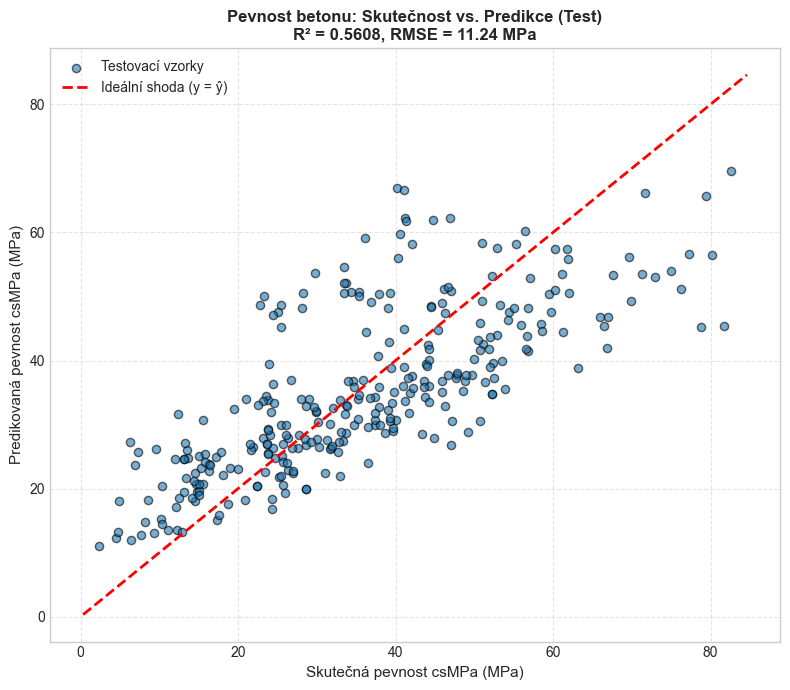

In [8]:
plt.figure(figsize=(8, 7))
plt.scatter(y_test, y_pred_test, color='#1f77b4', alpha=0.6, edgecolors='k', s=35, label='Testovací vzorky')

min_val = min(y_test.min(), y_pred_test.min()) - 2
max_val = max(y_test.max(), y_pred_test.max()) + 2
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideální shoda (y = ŷ)')

test_r2 = r2_score(y_test, y_pred_test)
test_rmse = root_mean_squared_error(y_test, y_pred_test)
plt.title(f'Pevnost betonu: Skutečnost vs. Predikce (Test)\nR² = {test_r2:.4f}, RMSE = {test_rmse:.2f} MPa', fontsize=12, fontweight='bold')
plt.xlabel('Skutečná pevnost csMPa (MPa)', fontsize=11)
plt.ylabel('Predikovaná pevnost csMPa (MPa)', fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 8. Diagnostika reziduí (Homoskedasticita a normalita chyb)

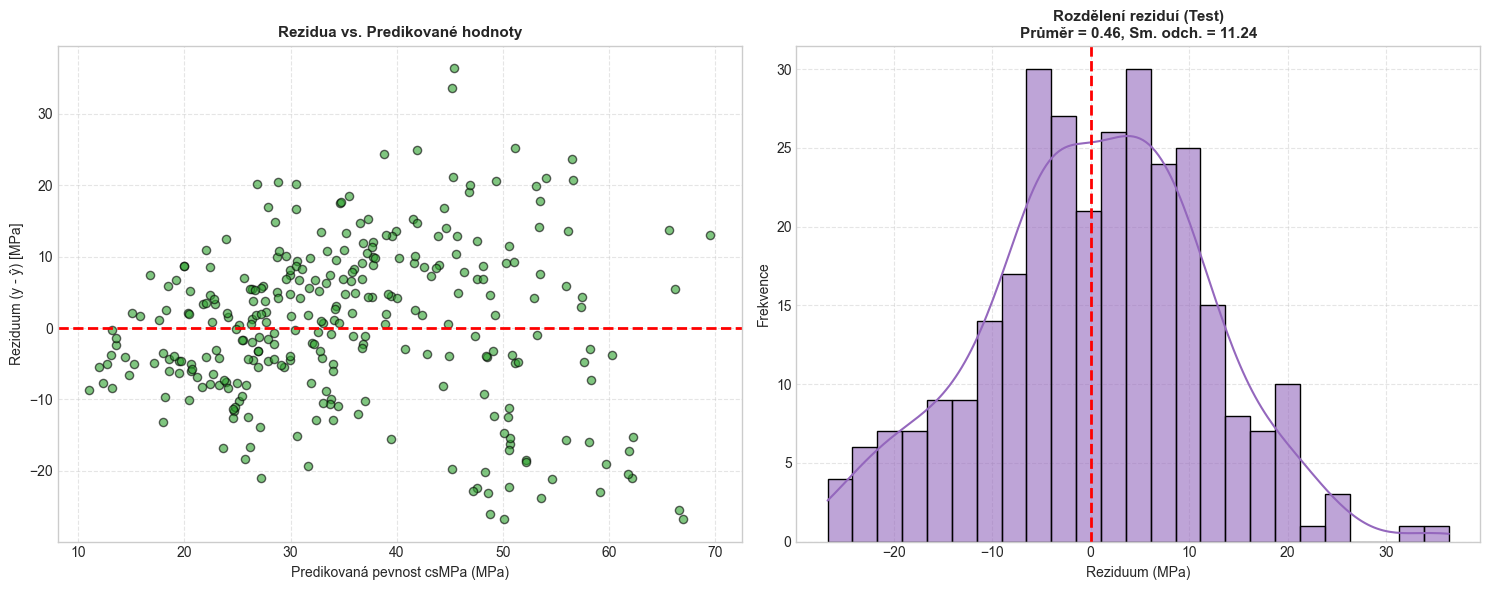

In [9]:
residuals_test = y_test - y_pred_test

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Scatter reziduí
ax1.scatter(y_pred_test, residuals_test, color='#2ca02c', alpha=0.6, edgecolors='k', s=35)
ax1.axhline(0, color='r', linestyle='--', linewidth=2)
ax1.set_title("Rezidua vs. Predikované hodnoty", fontsize=11, fontweight='bold')
ax1.set_xlabel("Predikovaná pevnost csMPa (MPa)")
ax1.set_ylabel("Reziduum (y - ŷ) [MPa]")
ax1.grid(True, linestyle='--', alpha=0.5)

# Histogram reziduí
sns.histplot(residuals_test, kde=True, color='#9467bd', ax=ax2, bins=25, edgecolor='black', alpha=0.6)
ax2.axvline(0, color='r', linestyle='--', linewidth=2)
ax2.set_title(f"Rozdělení reziduí (Test)\nPrůměr = {residuals_test.mean():.2f}, Sm. odch. = {residuals_test.std():.2f}", fontsize=11, fontweight='bold')
ax2.set_xlabel("Reziduum (MPa)")
ax2.set_ylabel("Frekvence")
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 9. Interpretace a zhodnocení výsledků

1. **Efektivita modelu:**
   - Model lineární regrese dosahuje na neviděných testovacích datech koeficientu determinace **$R^2 = 56.08\ \%$**.
   - Průměrná absolutní chyba činí **$\text{MAE} = 8.98\ \text{MPa}$** a odmocnina střední kvadratické chyby **$\text{RMSE} = 11.24\ \text{MPa}$**.
   - Vzhledem k rozsahu pevností betonu (od $2.3$ do $82.6\ \text{MPa}$) model zachycuje podstatnou část variance, avšak pro přesnou průmyslovou praxi (kde je tolerance okolo $\pm 3\ \text{MPa}$) je tato chyba relativně vysoká.

2. **Hierarchie vlivu složek (Fyzikální smysl koeficientů):**
   - **`cement` ($\beta = +12.79\ \text{MPa}$):** Zdaleka nejsilnější pozitivní motor pevnosti.
   - **`slag` ($\beta = +9.23\ \text{MPa}$) a `flyash` ($\beta = +6.05\ \text{MPa}$):** Potvrzují vysoký hydraulický a pucolánový přínos těchto průmyslových příměsí.
   - **`age` ($\beta = +7.13\ \text{MPa}$):** Doba zrání kompozitu.
   - **`water` ($\beta = -2.32\ \text{MPa}$):** Negativní koeficient odpovídá fyzikální realitě (Abramsův zákon – více záměsové vody vytváří po odpaření kapilární póry a oslabuje nosný skelet).

3. **Limity lineárního modelu:**
   - Skutečný vztah mezi stářím betonu a pevností není lineární, nýbrž **logaritmický** (exponenciální růst v prvních 28 dnech, následovaný nasycením).
   - Mezi vodou, cementem a plastifikátorem existují **silné nelineární interakce** (poměr $w/c$).
   - Tyto nelinearity představují příležitost pro pokročilejší modely (polynomiální regresi, rozhodovací stromy a ansámbly).
